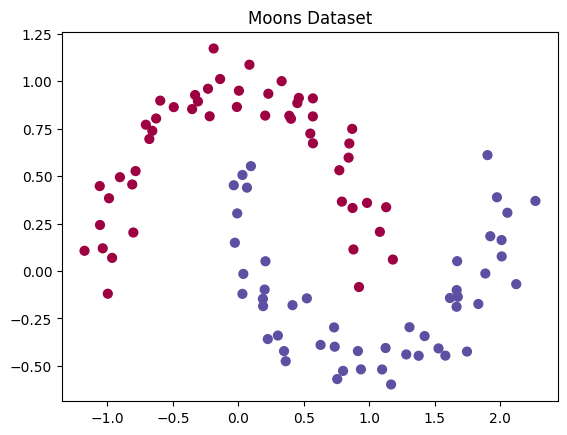

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from tensormicrograd.engine import Tensor
from tensormicrograd.nn import MLP

# Generate a non-linear dataset
X_np, y_np = make_moons(n_samples=100, noise=0.1, random_state=42)
y_np = y_np.reshape(-1, 1)
y_np = y_np * 2 - 1  # Convert labels to -1 and 1 for better convergence

# Visualize the input data
plt.scatter(X_np[:,0], X_np[:,1], c=y_np, s=40, cmap=plt.cm.Spectral)
plt.title("Moons Dataset")
plt.show()

In [33]:
# Initialize a Multi-Layer Perceptron (2 inputs -> two 16-neuron hidden layers -> 1 output)
model = MLP(2, [16, 16, 1])
print(f"Model initialized with {len(model.parameters())} parameters.")

epochs = 1000
learning_rate = 0.1

for k in range(epochs):
    # Wrap data in Tensors (Vectorized forward pass)
    inputs = Tensor(X_np)
    targets = Tensor(y_np)
    
    # Forward pass
    scores = model(inputs)
    
    # Loss: Mean Squared Error (MSE)
    diff = scores - targets
    loss = (diff ** 2).sum() * (1.0 / len(X_np))
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Learning rate decay: gradually reduce LR for better stability
    curr_lr = learning_rate * (1.0 - 0.5 * k / epochs)
    
    # Stochastic Gradient Descent (SGD) update
    for p in model.parameters():
        p.data -= curr_lr * p.grad
    
    if k % 50 == 0 or k == epochs - 1:
        # Calculate Accuracy
        predictions = scores.data > 0
        accuracy = np.mean(predictions == (y_np > 0))
        print(f"Step {k:3d} | Loss: {loss.data:.4f} | Accuracy: {accuracy*100:5.1f}%")

print("Training finished!")

Model initialized with 6 parameters.
Step   0 | Loss: 0.9964 | Accuracy:  66.0%
Step  50 | Loss: 0.3774 | Accuracy:  86.0%
Step 100 | Loss: 0.3206 | Accuracy:  87.0%
Step 150 | Loss: 0.3045 | Accuracy:  87.0%
Step 200 | Loss: 0.2975 | Accuracy:  87.0%
Step 250 | Loss: 0.2939 | Accuracy:  88.0%
Step 300 | Loss: 0.2903 | Accuracy:  88.0%
Step 350 | Loss: 0.2850 | Accuracy:  88.0%
Step 400 | Loss: 0.2764 | Accuracy:  89.0%
Step 450 | Loss: 0.2617 | Accuracy:  90.0%
Step 500 | Loss: 0.2334 | Accuracy:  91.0%
Step 550 | Loss: 0.1857 | Accuracy:  92.0%
Step 600 | Loss: 0.1206 | Accuracy:  97.0%
Step 650 | Loss: 0.0959 | Accuracy:  99.0%
Step 700 | Loss: 0.0865 | Accuracy:  99.0%
Step 750 | Loss: 0.0814 | Accuracy:  99.0%
Step 800 | Loss: 0.0771 | Accuracy: 100.0%
Step 850 | Loss: 0.0739 | Accuracy: 100.0%
Step 900 | Loss: 0.0718 | Accuracy: 100.0%
Step 950 | Loss: 0.0702 | Accuracy: 100.0%
Step 999 | Loss: 0.0690 | Accuracy: 100.0%
Training finished!


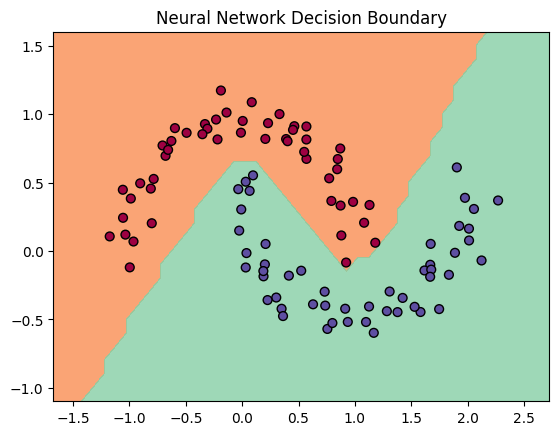

In [34]:
# Create a mesh grid to visualize the classification regions
h = 0.1
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Forward pass for the entire grid
X_grid = np.c_[xx.ravel(), yy.ravel()]
scores_grid = model(Tensor(X_grid))
Z = (scores_grid.data > 0).reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=40, edgecolors='k', cmap=plt.cm.Spectral)
plt.title("Neural Network Decision Boundary")
plt.show()